In [26]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
#{"username":"vaishnavibhan","key":"bcdc273030818e5efa2dfec817ff4690"}
import kagglehub
kagglehub.login()


In [27]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

system_threat_forecaster_path = kagglehub.competition_download('System-Threat-Forecaster')

print('Data source import complete.')


Data source import complete.


In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [29]:
df = pd.read_csv("train.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm                     

In [30]:
def dataset_overview(df):
    print(f"Shape of the dataset: {df.shape}")
    print("\nSample data:")
    print(df.head())
    print("\nData types and null value counts:")
    print(df.info())
    print("\nDescriptive statistics for numeric columns:")
    print(df.describe())
    print("\nMissing values by column:")
    missing_values = df.isnull().sum().sort_values(ascending=False)
    print(missing_values[missing_values > 0])
    return missing_values

# Example usage
missing_values = dataset_overview(df)


Shape of the dataset: (100000, 76)

Sample data:
                          MachineID   ProductName EngineVersion  \
0  f541bae429089117c4aac39c90dd3416  win8defender   1.1.15200.1   
1  dc2b14d9ce3a0ce4050bb640190f2ca5  win8defender   1.1.15100.1   
2  fd20c5f010e9c5f91ad1c6b3e0da68a0  win8defender   1.1.15200.1   
3  38711eae85eb77a72ec5dfdf27eb2a76  win8defender   1.1.15200.1   
4  32607c9a543a9214e2c7e45800ed4849  win8defender   1.1.15200.1   

         AppVersion SignatureVersion  IsBetaUser  RealTimeProtectionState  \
0   4.18.1807.18075     1.275.1003.0           0                      7.0   
1   4.18.1807.18075     1.273.1465.0           0                      7.0   
2   4.18.1807.18075     1.275.1546.0           0                      7.0   
3  4.12.17007.18011     1.275.1141.0           0                      7.0   
4    4.13.17134.228     1.275.1283.0           0                      7.0   

   IsPassiveModeEnabled  AntivirusConfigID  NumAntivirusProductsInstalled  \
0       

In [31]:
def high_cardinality_features(df, threshold=50):
    high_card_features = [
        col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() > threshold
    ]
    print(f"High cardinality categorical features: {high_card_features}")
    return high_card_features

# Example usage
high_card_features = high_cardinality_features(df)


High cardinality categorical features: ['MachineID', 'AppVersion', 'SignatureVersion', 'OSBuildLab', 'NumericOSVersion', 'DateAS', 'DateOS']


In [32]:
def feature_summary(df, target):
    summary = pd.DataFrame({
        "Feature": df.columns,
        "Data Type": [df[col].dtype for col in df.columns],
        "Unique Values": [df[col].nunique() for col in df.columns],
        "Missing Values": [df[col].isnull().sum() for col in df.columns],
        "Missing Percentage": [df[col].isnull().mean() * 100 for col in df.columns],
        "Correlation with Target": [
            df[col].corr(df[target]) if df[col].dtype in [float, int] else None
            for col in df.columns
        ]
    })
    print("Feature Summary:")
    print(summary)
    return summary

# Example usage
feature_summary_df = feature_summary(df, target="target")
feature_summary_df.to_csv("feature_summary.csv", index=False)


Feature Summary:
             Feature Data Type  Unique Values  Missing Values  \
0          MachineID    object          99835               0   
1        ProductName    object              2               0   
2      EngineVersion    object             37               0   
3         AppVersion    object             69               0   
4   SignatureVersion    object           2735               0   
..               ...       ...            ...             ...   
71           IsGamer   float64              2             559   
72  RegionIdentifier   float64             15             559   
73            DateAS    object           2695               0   
74            DateOS    object            112              24   
75            target     int64              2               0   

    Missing Percentage  Correlation with Target  
0                0.000                      NaN  
1                0.000                      NaN  
2                0.000                      NaN  
3 

/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


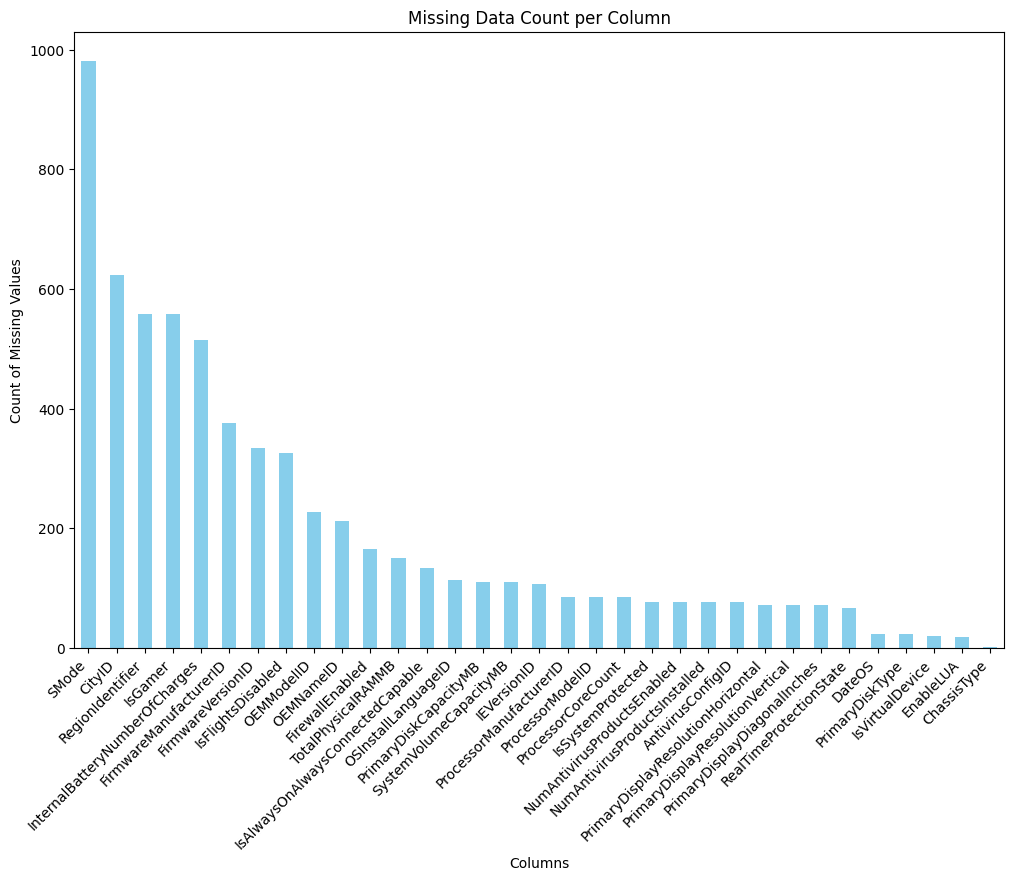

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate missing values
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]  # Filter only columns with missing values

# Plot bar graph
plt.figure(figsize=(12, 8))
missing_data.plot(kind='bar', color='skyblue')
plt.title("Missing Data Count per Column")
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.show()



Highly correlated pairs:
OSInstallLanguageID                 OSUILocaleID                          0.988082
OSUILocaleID                        OSInstallLanguageID                   0.988082
OSBuildNumber                       OSBuildNumberOnly                     0.947564
OSBuildNumberOnly                   OSBuildNumber                         0.947564
PrimaryDisplayResolutionHorizontal  PrimaryDisplayResolutionVertical      0.898174
PrimaryDisplayResolutionVertical    PrimaryDisplayResolutionHorizontal    0.898174
ProcessorManufacturerID             ProcessorModelID                      0.801885
ProcessorModelID                    ProcessorManufacturerID               0.801885
PrimaryDiskCapacityMB               SystemVolumeCapacityMB                0.771121
SystemVolumeCapacityMB              PrimaryDiskCapacityMB                 0.771121
RealTimeProtectionState             IsPassiveModeEnabled                 -0.901426
IsPassiveModeEnabled                RealTimeProtectionState   

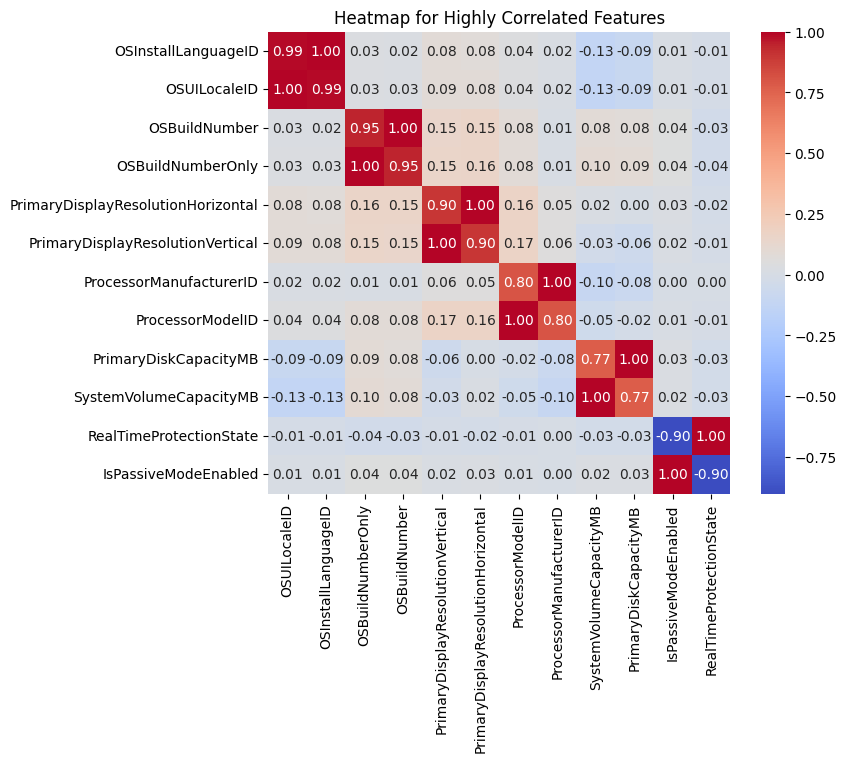

In [34]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Find the top correlations (excluding self-correlations)
correlation_threshold = 0.7  # Adjust the threshold as needed
high_corr_pairs = (
    corr_matrix
    .where((corr_matrix.abs() > correlation_threshold) & (corr_matrix != 1))
    .stack()
    .sort_values(ascending=False)
)

# Print the top correlated pairs
print("Highly correlated pairs:")
print(high_corr_pairs)

# Plot heatmap for only high correlations
if not high_corr_pairs.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix.loc[high_corr_pairs.index.get_level_values(0),
                                high_corr_pairs.index.get_level_values(1)],
                annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Heatmap for Highly Correlated Features")
    plt.show()
else:
    print("No correlations exceed the specified threshold.")


In [35]:
correlated_features = [
        col for col in df.columns
        if df[col].dtype in [float, int] and col != "target" and abs(df[col].corr(df["target"])) > 0
    ]
df_modified = df[correlated_features + ["target"]]
df_modified.shape

/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


(100000, 45)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [37]:
df_dropped = df.dropna()
df_dropped.shape

(96695, 76)

In [38]:
num_col = df.select_dtypes(include=['float64', 'int64']).columns
cat_col = df.select_dtypes(include=['object']).columns

num_na = [col for col in num_col if df[col].isna().sum() > 0]
cat_na = [col for col in cat_col if df[col].isna().sum() > 0]

print(len(num_col),len(cat_col))
print(len(num_na),len(cat_na))

48 28
30 3


In [39]:
df_imputed = df.copy()
df_imputed[num_col] = SimpleImputer(strategy='mean').fit_transform(df_imputed[num_col])
df_imputed[cat_col] = SimpleImputer(strategy='most_frequent').fit_transform(df_imputed[cat_col])
df_imputed.isna().sum().sum()
#without Imputer
# df_imputed = df.copy()
# for col in num_col :
#     df_imputed[col].fillna(df_imputed[col].mean(),inplace=True)
# for col in cat_col :
#     df_imputed[col].fillna(df_imputed[col].mode()[0],inplace=True)
# df_imputed.isna().sum().sum()

0

In [40]:
xtrain,xtest,ytrain,ytest = train_test_split(df,df["target"],test_size=0.1,random_state=42)
print(xtrain.shape,xtest.shape)

model = DummyClassifier(strategy="most_frequent")
model.fit(xtrain,ytrain)
ypred = model.predict(xtest)
print(accuracy_score(ytest,ypred))
print(classification_report(ytest,ypred))

(90000, 76) (10000, 76)
0.5106
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4894
           1       0.51      1.00      0.68      5106

    accuracy                           0.51     10000
   macro avg       0.26      0.50      0.34     10000
weighted avg       0.26      0.51      0.35     10000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
xtrain1,xtest1,ytrain1,ytest1 = train_test_split(df_dropped,df_dropped["target"],test_size=0.1,random_state=42)
print(xtrain1.shape,xtest1.shape)

model = DummyClassifier(strategy="stratified",random_state=237)
model.fit(xtrain1,ytrain1)
ypred_dropped = model.predict(xtest1)
print(accuracy_score(ytest1,ypred_dropped))
print(classification_report(ytest1,ypred_dropped))

(87025, 76) (9670, 76)
0.5084798345398138
              precision    recall  f1-score   support

           0       0.51      0.51      0.51      4823
           1       0.51      0.51      0.51      4847

    accuracy                           0.51      9670
   macro avg       0.51      0.51      0.51      9670
weighted avg       0.51      0.51      0.51      9670



In [42]:
xtrain2,xtest2,ytrain2,ytest2 = train_test_split(df_imputed,df_imputed["target"],test_size=0.1,random_state=42)
print(xtrain2.shape,xtest2.shape)

model = DummyClassifier(strategy="most_frequent")
model.fit(xtrain2,ytrain2)
ypred_imputed = model.predict(xtest2)
print(accuracy_score(ytest2,ypred_imputed))
print(classification_report(ytest2,ypred_imputed))

(90000, 76) (10000, 76)
0.5106
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      4894
         1.0       0.51      1.00      0.68      5106

    accuracy                           0.51     10000
   macro avg       0.26      0.50      0.34     10000
weighted avg       0.26      0.51      0.35     10000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
from sklearn.linear_model import LogisticRegression
df1 = df_modified.dropna()

xtrain3,xtest3,ytrain3,ytest3 = train_test_split(df1,df1["target"],test_size=0.1,random_state=42)
print(xtrain3.shape,xtest3.shape)

model = LogisticRegression()
model.fit(xtrain3,ytrain3)
ypred1 = model.predict(xtest3)
print(accuracy_score(ytest3,ypred1))
print(classification_report(ytest3,ypred1))


(87088, 45) (9677, 45)
0.5469670352381937
              precision    recall  f1-score   support

           0       0.57      0.40      0.47      4856
           1       0.53      0.70      0.60      4821

    accuracy                           0.55      9677
   macro avg       0.55      0.55      0.54      9677
weighted avg       0.55      0.55      0.54      9677



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
